**Seasonal Agriculture Performance Analysis**

**Major Data Analytics Project**

**Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### **Project Goal**

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

**Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.


##1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

### 2. Project Objectives

* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
* Identify significant findings from the data.
* Develop evidence-based insights and recommendations.


### 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

# 4. Analytical Plan

This notebook follows the project brief and focuses specifically on **seasonal agricultural performance**.

### Questions investigated
1. How does agricultural performance vary across Kharif, Rabi and Zaid seasons?
2. Which seasonal conditions and resource-use variables are associated with yield and profit?
3. How do crops and irrigation methods perform across seasons?
4. Which unusual observations require investigation?
5. What evidence-based recommendations can support better seasonal agricultural planning?

### Required checklist covered
- Dataset loading and verification
- Top 5 rows
- Shape, structure and data types
- Missing values and treatment
- Duplicate detection and treatment
- Descriptive/statistical analysis
- Outlier investigation
- Univariate, bivariate and multivariate analysis
- Correlation analysis
- Seasonal comparisons
- 3+ student-designed analyses
- 8+ documented insights
- Evidence-based recommendations
- Limitations
- Final conclusion

In [1]:
# 5. Import libraries and configure the analysis
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "/content/seasonal_agriculture_performance_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully: 4,000 rows × 28 columns


In [2]:
# 6. Top 5 rows analyzed
display(df.head(5))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
# 7. Dataset shape and structure
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset info:")
display(pd.DataFrame({
    "Column": df.columns,
    "Non_Null_Count": df.notna().sum().values,
    "Unique_Values": df.nunique().values,
    "Data_Type": df.dtypes.astype(str).values
}))

Shape: (4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset info:


,Column,Non_Null_Count,Unique_Values,Data_Type
0,Farm_ID,4000,4000,object
1,State,4000,8,object
2,District,4000,10,object
3,Crop,4000,8,object
4,Season,4000,3,object
5,Farm_Area_Hectares,4000,1370,float64
6,Rainfall_mm,3952,3256,float64
7,Avg_Temperature_C,4000,204,float64
8,Humidity_pct,4000,573,float64
9,Sunlight_Hours_Day,4000,71,float64


In [4]:
# 8. Data types examined
dtype_summary = df.dtypes.value_counts().rename_axis("Data_Type").reset_index(name="Number_of_Columns")
display(dtype_summary)

print("Categorical columns:", df.select_dtypes(include="object").columns.tolist())
print("Numerical columns:", df.select_dtypes(include=np.number).columns.tolist())

,Data_Type,Number_of_Columns
0,float64,17
1,object,6
2,int64,5


Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']
Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


## 9. Data Quality: Missing Values

Missing observations are identified before analysis. For the numerical fields with missing values, the project uses **season-wise median imputation**. This is preferable to a single overall median because the project is explicitly about seasonal differences and the distributions can differ between seasons.

No duplicate Farm_ID/record is expected to represent a separate farm record after duplicate checking.

In [5]:
# 9.1 Missing-value audit
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean().mul(100)
}).sort_values("Missing_Count", ascending=False)

display(missing_summary[missing_summary["Missing_Count"] > 0])

print("Total missing cells:", int(df.isna().sum().sum()))

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


Total missing cells: 120


In [6]:
# 9.2 Duplicate audit
duplicate_rows = int(df.duplicated().sum())
duplicate_ids = int(df["Farm_ID"].duplicated().sum())

print(f"Duplicate complete rows: {duplicate_rows}")
print(f"Duplicate Farm_ID values: {duplicate_ids}")

if duplicate_rows == 0 and duplicate_ids == 0:
    print("No duplicate records were found; no rows were removed.")

Duplicate complete rows: 0
Duplicate Farm_ID values: 0
No duplicate records were found; no rows were removed.


In [7]:
# 9.3 Handle missing numerical values using season-wise medians
df_clean = df.copy()

numeric_missing_cols = df_clean.select_dtypes(include=np.number).columns[
    df_clean.select_dtypes(include=np.number).isna().any()
].tolist()

for col in numeric_missing_cols:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda s: s.fillna(s.median())
    )

remaining_missing = int(df_clean.isna().sum().sum())

print("Columns imputed:", numeric_missing_cols)
print("Remaining missing cells after treatment:", remaining_missing)
print("Clean dataset shape:", df_clean.shape)

Columns imputed: ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
Remaining missing cells after treatment: 0
Clean dataset shape: (4000, 28)


## 10. Descriptive / Statistical Analysis

The following summaries compare central tendency and spread. Because several variables contain extreme values, both **mean and median** are considered. For financial outcomes, profit margin and the percentage of profitable farms are also calculated to make comparisons more interpretable.

In [8]:
# 10.1 Overall numerical descriptive statistics
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [9]:
# 10.2 Seasonal descriptive statistics
season_order = [s for s in ["Kharif", "Rabi", "Zaid"] if s in df_clean["Season"].unique()]

season_summary = df_clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Mean_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Mean_Production=("Production_Tonnes", "mean"),
    Mean_Revenue=("Revenue_INR", "mean"),
    Mean_Cost=("Total_Cost_INR", "mean"),
    Mean_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Mean_Water_Use=("Water_Used_m3", "mean"),
    Mean_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Mean_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
).reindex(season_order)

season_summary["Profit_Margin_pct"] = (
    season_summary["Mean_Profit"] / season_summary["Mean_Revenue"] * 100
)
season_summary["Profitable_Farm_Rate_pct"] = (
    df_clean.assign(Profitable=df_clean["Profit_INR"] > 0)
    .groupby("Season")["Profitable"].mean()
    .reindex(season_order) * 100
)

display(season_summary.round(2))

,Farms,Mean_Yield,Median_Yield,Mean_Production,Mean_Revenue,Mean_Cost,Mean_Profit,Median_Profit,Mean_Water_Use,Mean_Water_Efficiency,Mean_Disease_Risk,Profit_Margin_pct,Profitable_Farm_Rate_pct
Season,,,,,,,,,,,,,
Kharif,1779,5.63,1.95,46.31,"710,719.06","531,804.41","178,914.65","38,808.00","6,102.20",5.89,54.47,25.17,57.79
Rabi,1627,5.04,1.66,41.49,"601,526.05","513,836.58","87,689.47","-3,187.00","5,846.99",5.19,40.48,14.58,48.86
Zaid,594,4.64,1.45,38.89,"519,171.90","543,976.73","-24,804.82","-62,144.00","6,419.89",4.41,38.22,-4.78,35.52


## 11. Outlier Investigation

Outliers are investigated using the **1.5 × IQR rule**. An outlier is not automatically deleted: a genuine high-yield/high-profit farm can be a valid observation. The analysis therefore reports outlier counts and visualizes key variables before deciding whether removal is justified.

In this dataset, financial and production variables can have very wide ranges, so removing them blindly could hide meaningful agricultural differences.

In [10]:
# 11.1 IQR-based outlier summary
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
outlier_rows = []

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    outlier_rows.append([col, q1, q3, lower, upper, count, count / len(df_clean) * 100])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "Q1", "Q3", "Lower_Bound", "Upper_Bound", "Outlier_Count", "Outlier_Percentage"]
).sort_values("Outlier_Count", ascending=False)

display(outlier_summary.head(15).round(2))

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302,7.55
19,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,86.20,123.60,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,6.60,8.10,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,46.20,69.40,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,143.98,227.20,19.14,352.04,15,0.38


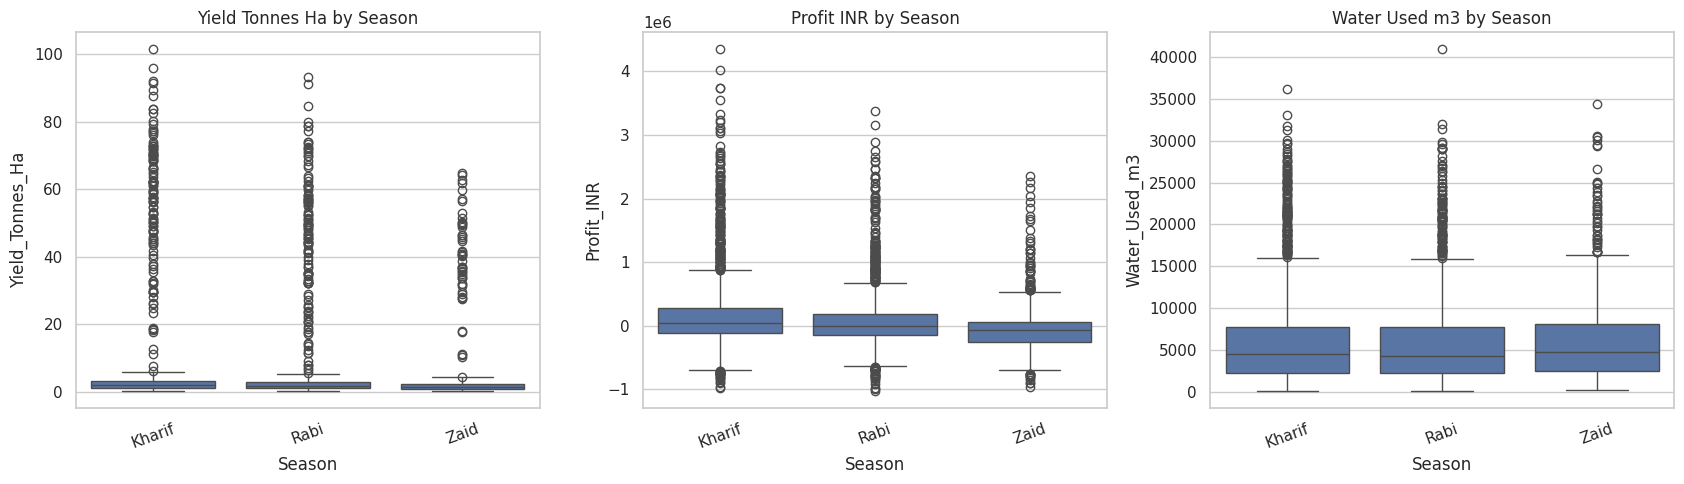

Interpretation: observations outside the IQR fences are flagged for investigation, not automatically removed.


In [11]:
# 11.2 Visual investigation of key outlier-prone variables
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3"]):
    sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax)
    ax.set_title(f"{col.replace('_', ' ')} by Season")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Interpretation: observations outside the IQR fences are flagged for investigation, not automatically removed.")

# 12. Univariate Analysis

Univariate analysis examines individual variables and their distributions. The plots below focus on the main outcome measures: yield, profit, rainfall, water use and disease/pest risk.

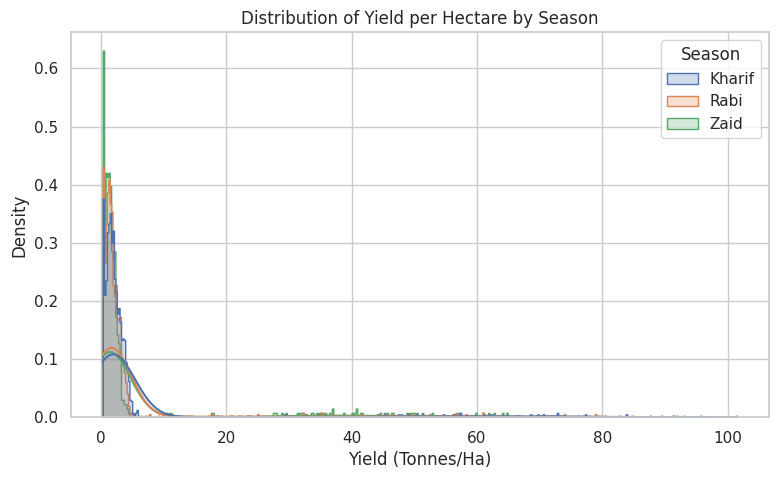

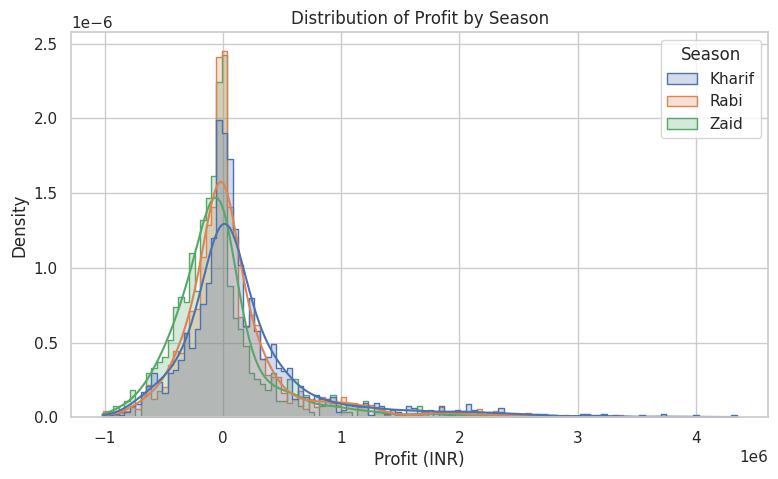

In [12]:
# 12.1 Seasonal distribution of yield
plt.figure(figsize=(9, 5))
sns.histplot(data=df_clean, x="Yield_Tonnes_Ha", hue="Season", kde=True, element="step", stat="density", common_norm=False)
plt.title("Distribution of Yield per Hectare by Season")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Density")
plt.show()

# 12.2 Profit distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df_clean, x="Profit_INR", hue="Season", kde=True, element="step", stat="density", common_norm=False)
plt.title("Distribution of Profit by Season")
plt.xlabel("Profit (INR)")
plt.ylabel("Density")
plt.show()

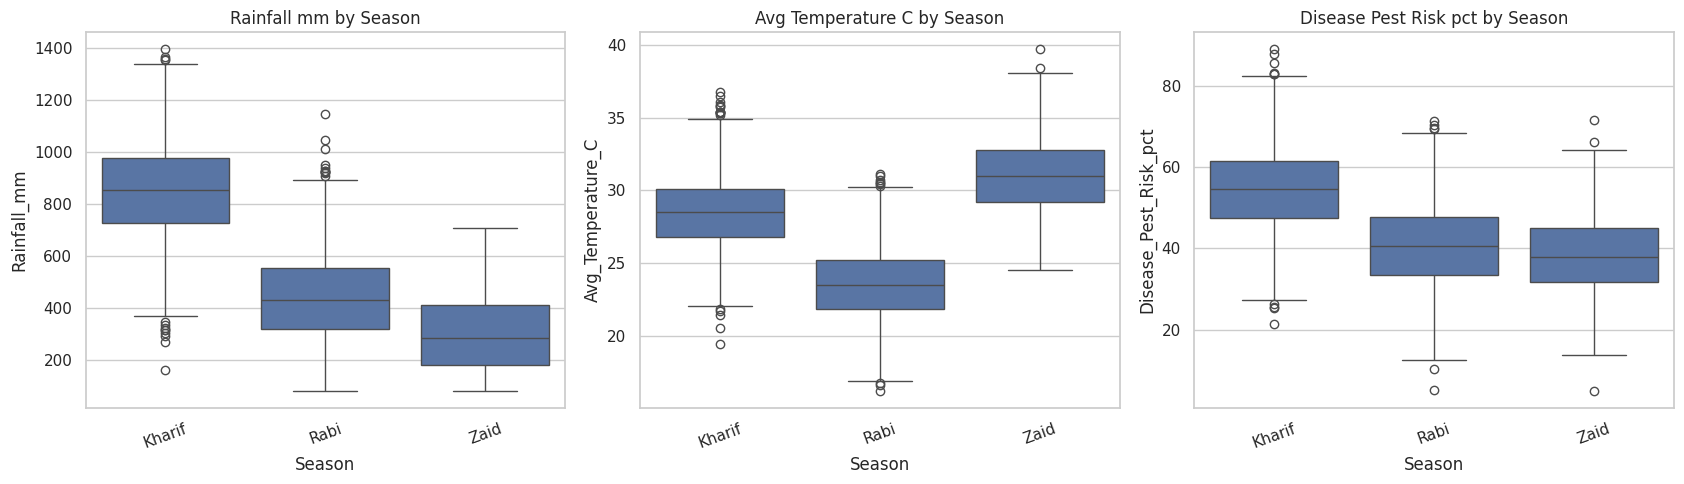

In [13]:
# 12.3 Seasonal boxplots for key environmental variables
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(
    axes,
    ["Rainfall_mm", "Avg_Temperature_C", "Disease_Pest_Risk_pct"]
):
    sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax)
    ax.set_title(f"{col.replace('_', ' ')} by Season")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 13. Bivariate Analysis

Bivariate analysis examines relationships between two variables. The first comparisons connect environmental conditions to yield, and the second connects resource use to financial performance.

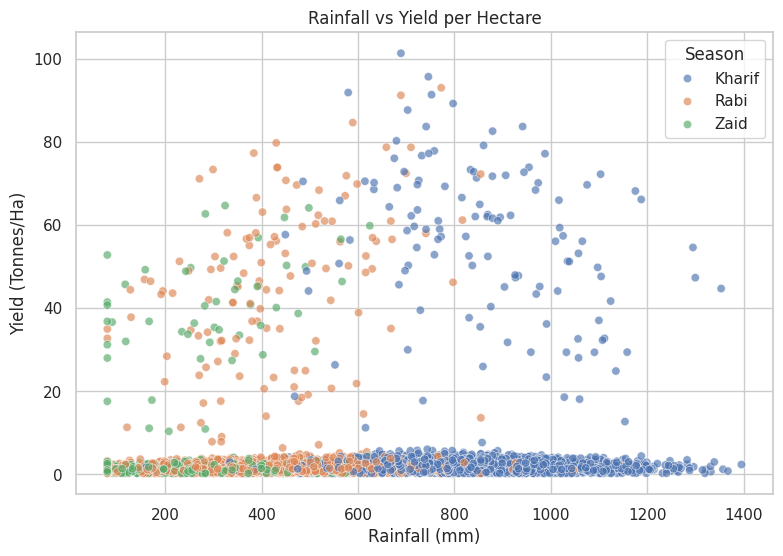

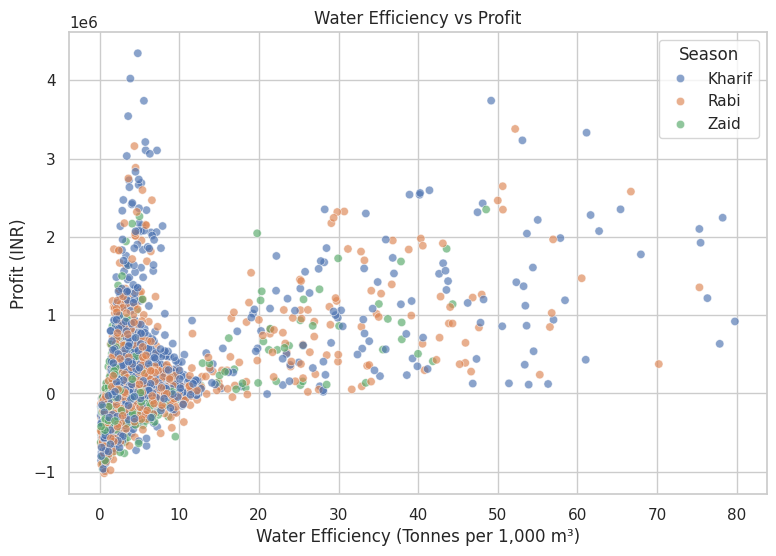

In [14]:
# 13.1 Rainfall vs Yield
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.65
)
plt.title("Rainfall vs Yield per Hectare")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

# 13.2 Water efficiency vs profit
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_clean,
    x="Water_Efficiency_t_per_1000m3",
    y="Profit_INR",
    hue="Season",
    alpha=0.65
)
plt.title("Water Efficiency vs Profit")
plt.xlabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.ylabel("Profit (INR)")
plt.show()

# 14. Multivariate Analysis

Multivariate analysis considers several dimensions at once. Here, yield, profit, farm area and season are examined together to understand whether high-output observations are also financially successful and whether the pattern differs by season.

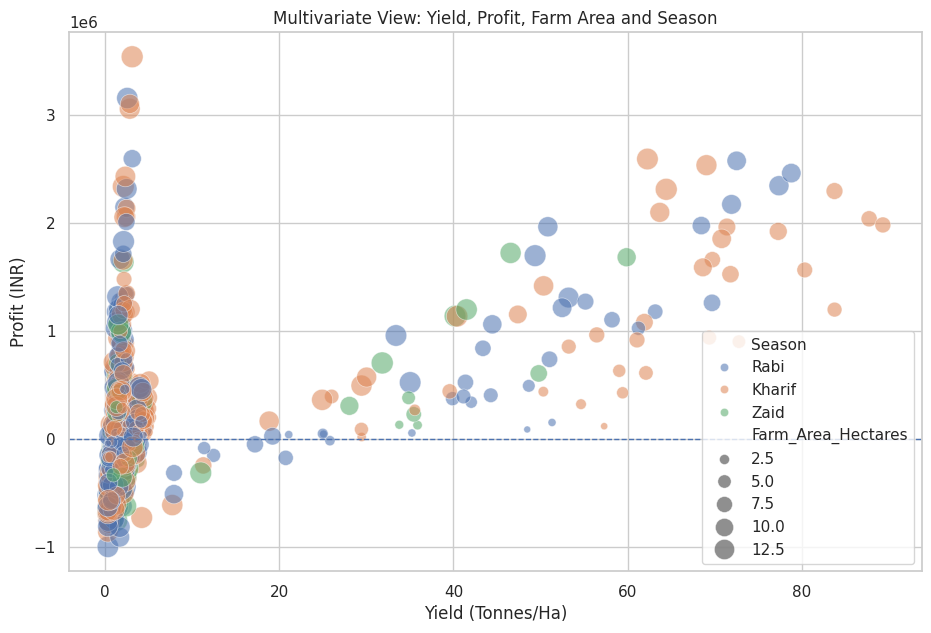

In [15]:
# 14.1 Multivariate bubble-style scatter: yield, profit, farm area and season
plot_df = df_clean.sample(min(1200, len(df_clean)), random_state=42)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=plot_df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 250),
    alpha=0.55
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Multivariate View: Yield, Profit, Farm Area and Season")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.show()

# 15. Correlation Analysis

Pearson correlation is used as a screening tool for linear association among numerical variables. Correlation indicates association, **not causation**. Strong correlations involving revenue, production and yield are expected to be particularly relevant when explaining profit.

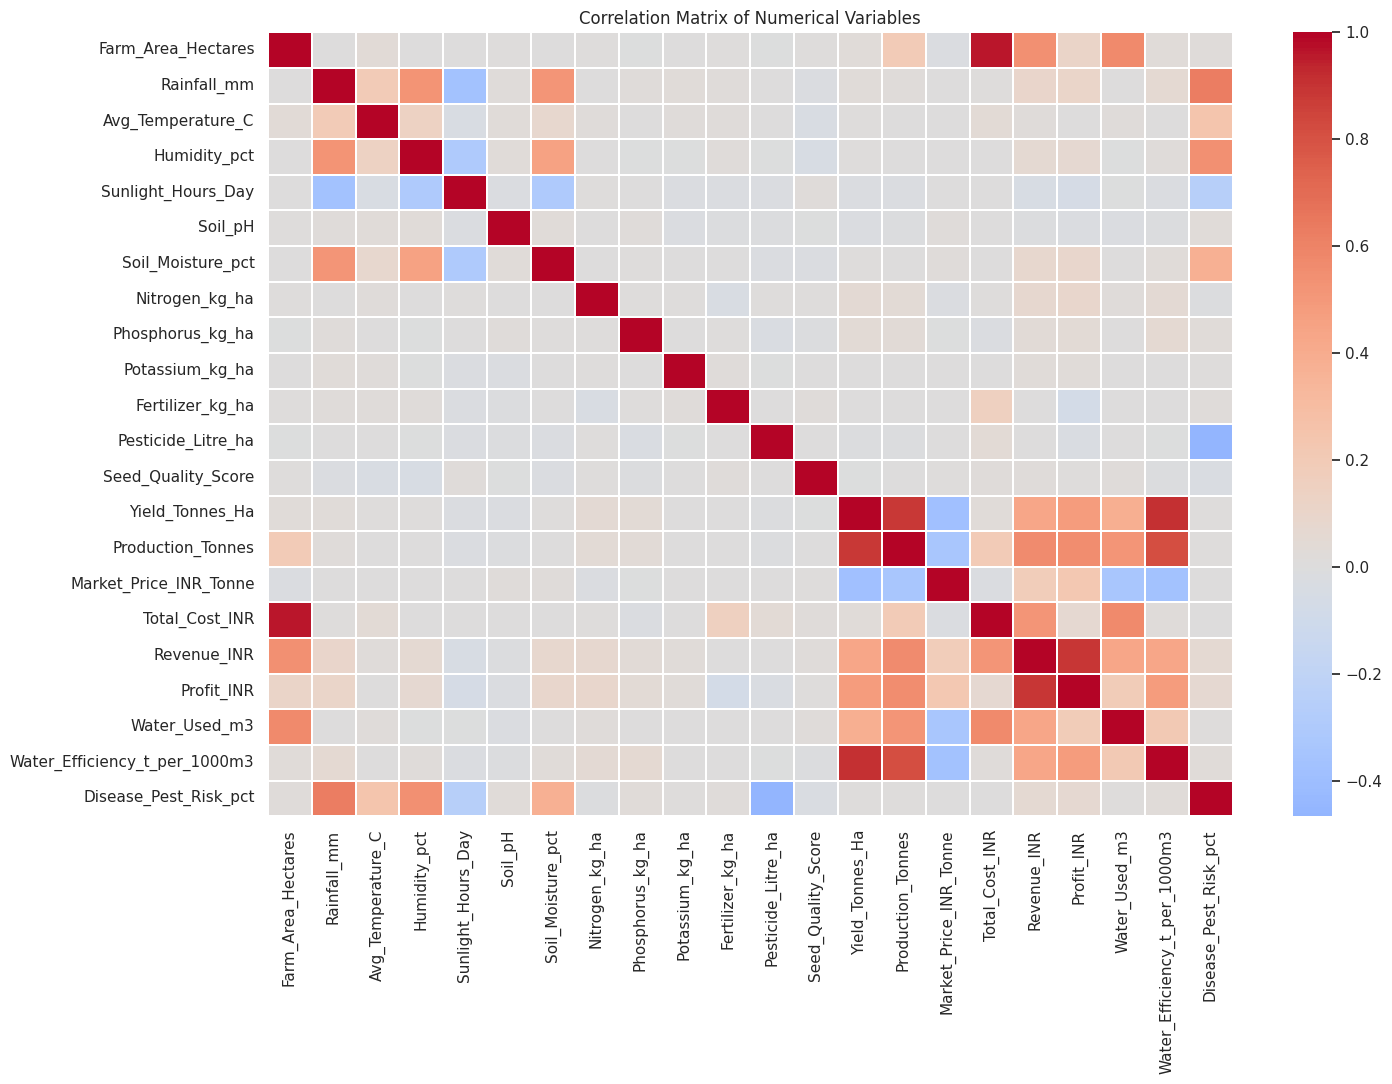

,Correlation_with_Profit
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11
Soil_Moisture_pct,0.09


In [16]:
# 15.1 Correlation matrix
corr = df_clean.select_dtypes(include=np.number).corr()

plt.figure(figsize=(15, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

profit_corr = corr["Profit_INR"].sort_values(ascending=False)
display(profit_corr.to_frame("Correlation_with_Profit"))

# 16. Seasonal Comparisons

This section directly addresses the project requirement to compare performance across seasons. Both mean and median values are shown because extreme observations can materially affect means.

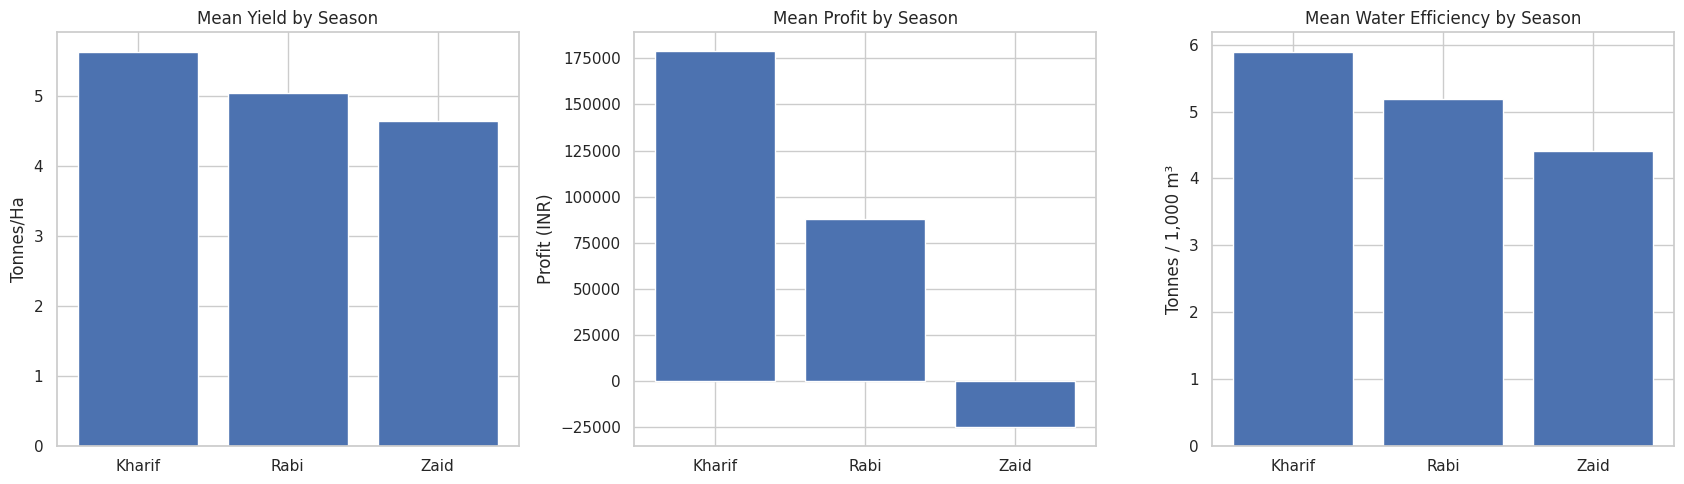

,Farms,Mean_Yield,Median_Yield,Mean_Profit,Median_Profit,Profit_Margin_pct,Profitable_Farm_Rate_pct,Mean_Water_Efficiency,Mean_Disease_Risk
Season,,,,,,,,,
Kharif,1779,5.63,1.95,"178,914.65","38,808.00",25.17,57.79,5.89,54.47
Rabi,1627,5.04,1.66,"87,689.47","-3,187.00",14.58,48.86,5.19,40.48
Zaid,594,4.64,1.45,"-24,804.82","-62,144.00",-4.78,35.52,4.41,38.22


In [17]:
# 16.1 Seasonal comparison of key performance measures
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(season_order, [season_summary.loc[s, "Mean_Yield"] for s in season_order])
axes[0].set_title("Mean Yield by Season")
axes[0].set_ylabel("Tonnes/Ha")

axes[1].bar(season_order, [season_summary.loc[s, "Mean_Profit"] for s in season_order])
axes[1].set_title("Mean Profit by Season")
axes[1].set_ylabel("Profit (INR)")

axes[2].bar(season_order, [season_summary.loc[s, "Mean_Water_Efficiency"] for s in season_order])
axes[2].set_title("Mean Water Efficiency by Season")
axes[2].set_ylabel("Tonnes / 1,000 m³")

plt.tight_layout()
plt.show()

display(season_summary[[
    "Farms", "Mean_Yield", "Median_Yield", "Mean_Profit", "Median_Profit",
    "Profit_Margin_pct", "Profitable_Farm_Rate_pct",
    "Mean_Water_Efficiency", "Mean_Disease_Risk"
]].round(2))

# 17. Student-Designed Analysis 1 — Seasonal Profitability Quality

Instead of comparing only average profit, this analysis uses **profit margin** and **profitable-farm rate**. This gives a more balanced view of seasonal financial performance and reduces the risk of judging a season from mean profit alone.

,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Profitable_Farms,Profit_Margin_pct
Season,,,,,,
Kharif,"710,719.06","531,804.41","178,914.65","38,808.00",57.79,25.17
Rabi,"601,526.05","513,836.58","87,689.47","-3,187.00",48.86,14.58
Zaid,"519,171.90","543,976.73","-24,804.82","-62,144.00",35.52,-4.78


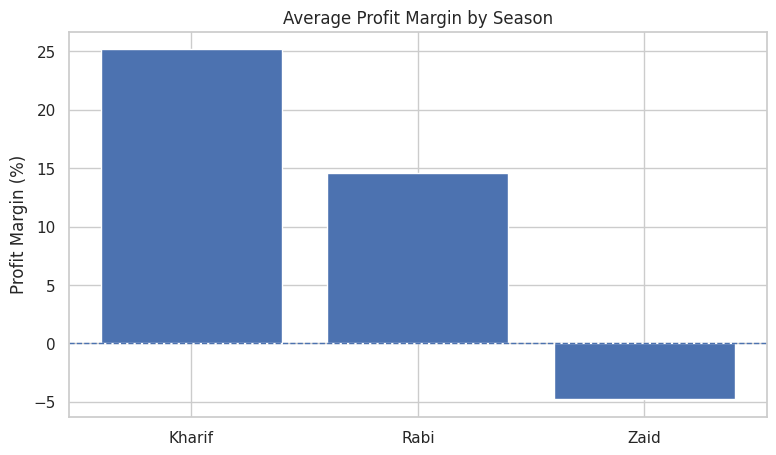

In [18]:
# Student-designed analysis 1
profitability = df_clean.groupby("Season").agg(
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Profitable_Farms=("Profit_INR", lambda s: (s > 0).mean() * 100)
).reindex(season_order)

profitability["Profit_Margin_pct"] = profitability["Avg_Profit"] / profitability["Avg_Revenue"] * 100
display(profitability.round(2))

plt.figure(figsize=(9, 5))
plt.bar(season_order, [profitability.loc[s, "Profit_Margin_pct"] for s in season_order])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average Profit Margin by Season")
plt.ylabel("Profit Margin (%)")
plt.show()

# 18. Student-Designed Analysis 2 — Irrigation Method Performance

Irrigation is evaluated using yield, water efficiency and profit. The analysis is split by season because an irrigation method that performs well overall may not perform equally well under different seasonal conditions.

,Season,Irrigation_Method,Avg_Yield,Avg_Water_Efficiency,Avg_Profit,Farms
0,Kharif,Drip,7.26,6.80,"317,222.07",405
2,Kharif,Rainfed,5.70,8.85,"158,974.13",463
1,Kharif,Flood,4.98,3.64,"133,373.83",590
3,Kharif,Sprinkler,4.66,4.62,"116,880.49",321
4,Rabi,Drip,6.11,6.05,"187,843.22",370
7,Rabi,Sprinkler,5.31,4.64,"76,502.07",293
5,Rabi,Flood,5.06,3.48,"58,824.80",526
6,Rabi,Rainfed,3.93,6.87,"45,232.48",438
11,Zaid,Sprinkler,6.13,4.86,"57,909.40",120
8,Zaid,Drip,5.85,5.30,"21,291.84",140


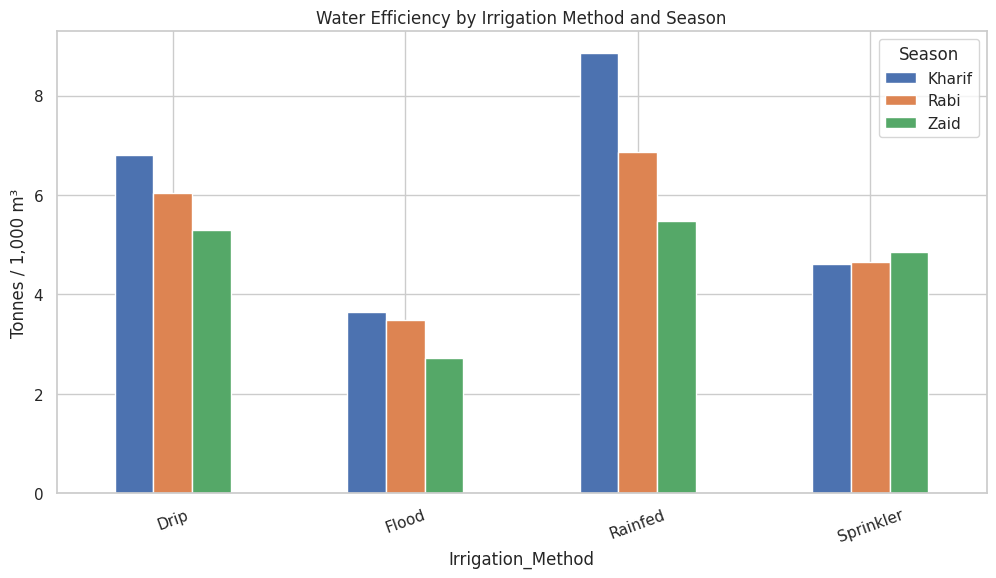

In [19]:
# Student-designed analysis 2
irrigation_season = df_clean.groupby(["Season", "Irrigation_Method"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Farms=("Farm_ID", "count")
).reset_index()

display(
    irrigation_season.sort_values(
        ["Season", "Avg_Profit"], ascending=[True, False]
    ).round(2)
)

plt.figure(figsize=(12, 6))
pivot_eff = irrigation_season.pivot(
    index="Irrigation_Method", columns="Season", values="Avg_Water_Efficiency"
).reindex(columns=season_order)
pivot_eff.plot(kind="bar", figsize=(12, 6), ax=plt.gca())
plt.title("Water Efficiency by Irrigation Method and Season")
plt.ylabel("Tonnes / 1,000 m³")
plt.xticks(rotation=20)
plt.show()

# 19. Student-Designed Analysis 3 — Crop × Season Opportunity Matrix

This analysis identifies which crop-season combinations combine stronger profitability with a reasonable number of observations. A heatmap makes seasonal opportunities and weak combinations easier to compare.

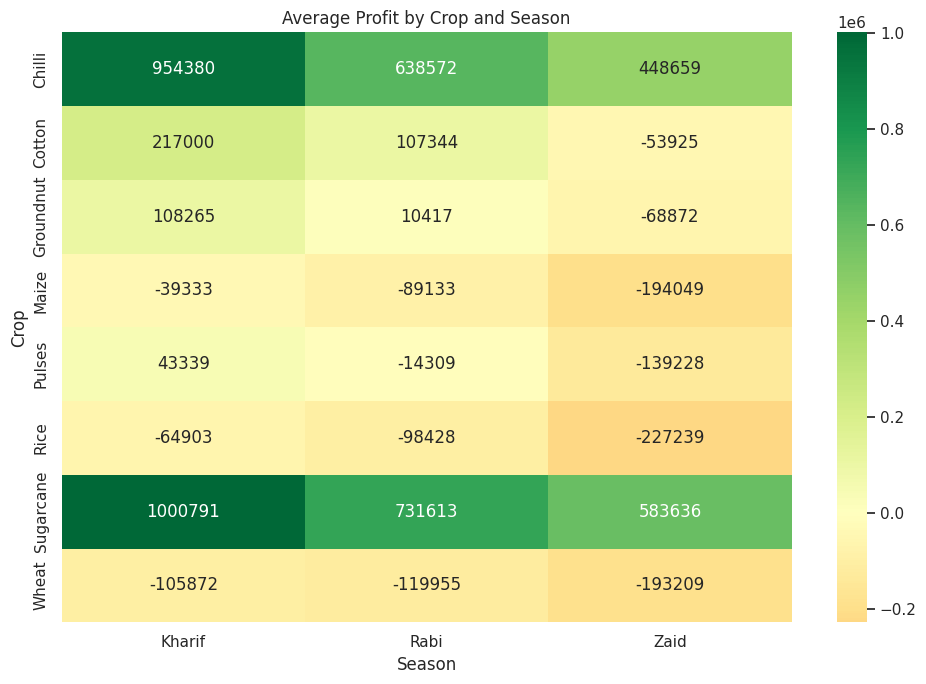

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


In [20]:
# Student-designed analysis 3
crop_season_profit = df_clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=season_order)

plt.figure(figsize=(10, 7))
sns.heatmap(crop_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

# Supporting table with observation counts
crop_season_counts = pd.crosstab(df_clean["Crop"], df_clean["Season"]).reindex(columns=season_order)
display(crop_season_counts)

# 20. Additional Student-Designed Analysis 4 — Seasonal Risk–Return Profile

A season can have high average profit but also high disease/pest risk. This analysis compares **profit margin, disease/pest risk and profitable-farm rate** together to identify the overall risk–return profile.

,Profit_Margin_pct,Disease_Pest_Risk_pct,Profitable_Farm_Rate_pct,Mean_Yield
Season,,,,
Kharif,25.17,54.47,57.79,5.63
Rabi,14.58,40.48,48.86,5.04
Zaid,-4.78,38.22,35.52,4.64


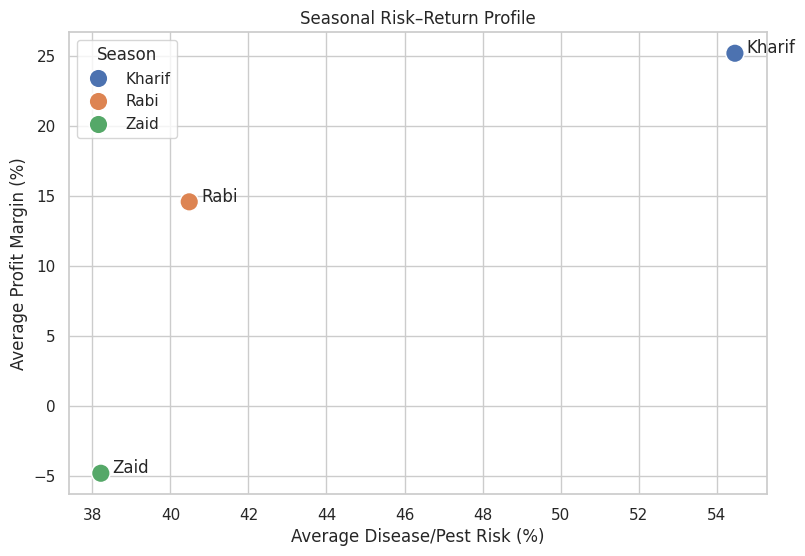

In [21]:
risk_return = df_clean.groupby("Season").agg(
    Profit_Margin_pct=("Profit_INR", lambda s: s.mean() / df_clean.loc[s.index, "Revenue_INR"].mean() * 100),
    Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
    Profitable_Farm_Rate_pct=("Profit_INR", lambda s: (s > 0).mean() * 100),
    Mean_Yield=("Yield_Tonnes_Ha", "mean")
).reindex(season_order)

display(risk_return.round(2))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=risk_return.reset_index(),
    x="Disease_Pest_Risk_pct",
    y="Profit_Margin_pct",
    hue="Season",
    s=180
)
for _, row in risk_return.reset_index().iterrows():
    plt.text(row["Disease_Pest_Risk_pct"] + 0.3, row["Profit_Margin_pct"], row["Season"])
plt.title("Seasonal Risk–Return Profile")
plt.xlabel("Average Disease/Pest Risk (%)")
plt.ylabel("Average Profit Margin (%)")
plt.show()

# 21. Evidence-Based Insights

The following insights are generated directly from the cleaned dataset and the analyses above. They are descriptive findings, not claims of causation.

In [22]:
# Generate 8+ evidence-based insights from the observed data
best_profit_season = season_summary["Mean_Profit"].idxmax()
worst_profit_season = season_summary["Mean_Profit"].idxmin()
best_yield_season = season_summary["Mean_Yield"].idxmax()
best_water_season = season_summary["Mean_Water_Efficiency"].idxmax()
lowest_risk_season = season_summary["Mean_Disease_Risk"].idxmin()

top_profit_corr = profit_corr.drop("Profit_INR").index[0]
top_profit_corr_value = profit_corr.drop("Profit_INR").iloc[0]

best_crop = df_clean.groupby("Crop")["Profit_INR"].mean().idxmax()
best_crop_profit = df_clean.groupby("Crop")["Profit_INR"].mean().max()

best_irrigation = df_clean.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmax()
best_irrigation_eff = df_clean.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().max()

overall_positive_rate = (df_clean["Profit_INR"] > 0).mean() * 100

insights = [
    f"1. {best_profit_season} has the highest mean profit at ₹{season_summary.loc[best_profit_season, 'Mean_Profit']:,.0f}, while {worst_profit_season} has the lowest at ₹{season_summary.loc[worst_profit_season, 'Mean_Profit']:,.0f}.",
    f"2. Mean yield is highest in {best_yield_season} ({season_summary.loc[best_yield_season, 'Mean_Yield']:.2f} tonnes/ha), indicating a clear seasonal difference in production performance.",
    f"3. The median yield is lower than the mean in every season, showing that high-yield observations are pulling the averages upward and making medians important for interpretation.",
    f"4. {best_profit_season} has the highest profitable-farm rate at {season_summary.loc[best_profit_season, 'Profitable_Farm_Rate_pct']:.1f}%, compared with {season_summary.loc[worst_profit_season, 'Profitable_Farm_Rate_pct']:.1f}% in {worst_profit_season}.",
    f"5. {best_water_season} records the highest mean water efficiency at {season_summary.loc[best_water_season, 'Mean_Water_Efficiency']:.2f} tonnes per 1,000 m³ among the three seasons.",
    f"6. {lowest_risk_season} has the lowest average disease/pest risk ({season_summary.loc[lowest_risk_season, 'Mean_Disease_Risk']:.2f}%), while the highest-risk season is {season_summary['Mean_Disease_Risk'].idxmax()}.",
    f"7. Profit is most strongly positively correlated with {top_profit_corr} (r = {top_profit_corr_value:.3f}) among the numerical variables, indicating a strong linear association in this dataset.",
    f"8. Across all records, {overall_positive_rate:.1f}% of farms have positive profit, so profitability is not guaranteed even when production occurs.",
    f"9. {best_crop} has the highest average crop-level profit at ₹{best_crop_profit:,.0f}; crop choice therefore appears important for financial outcomes in the observed records.",
    f"10. {best_irrigation} has the highest overall mean water efficiency at {best_irrigation_eff:.2f} tonnes per 1,000 m³, although the irrigation comparison also shows that performance varies by season."
]

for item in insights:
    print(item)

1. Kharif has the highest mean profit at ₹178,915, while Zaid has the lowest at ₹-24,805.
2. Mean yield is highest in Kharif (5.63 tonnes/ha), indicating a clear seasonal difference in production performance.
3. The median yield is lower than the mean in every season, showing that high-yield observations are pulling the averages upward and making medians important for interpretation.
4. Kharif has the highest profitable-farm rate at 57.8%, compared with 35.5% in Zaid.
5. Kharif records the highest mean water efficiency at 5.89 tonnes per 1,000 m³ among the three seasons.
6. Zaid has the lowest average disease/pest risk (38.22%), while the highest-risk season is Kharif.
7. Profit is most strongly positively correlated with Revenue_INR (r = 0.887) among the numerical variables, indicating a strong linear association in this dataset.
8. Across all records, 50.8% of farms have positive profit, so profitability is not guaranteed even when production occurs.
9. Sugarcane has the highest aver

# 22. Evidence-Based Recommendations

Based on the observed patterns:

1. **Prioritize seasonal planning:** Use the stronger-performing season as a benchmark for planning, while investigating why the weakest season has lower profitability.
2. **Do not optimize for yield alone:** Evaluate yield together with revenue, cost and profit because high production does not automatically imply positive financial performance.
3. **Use water-efficiency metrics:** Compare irrigation methods using both water efficiency and profit rather than water use alone.
4. **Evaluate crop–season combinations:** Crop selection should consider the season-specific profitability matrix rather than relying only on overall crop averages.
5. **Monitor disease/pest risk:** Seasons with higher observed risk should receive stronger preventive monitoring and resource planning.
6. **Investigate extreme observations:** High-profit/high-yield records should be validated rather than automatically deleted, because they may represent genuine successful farms or unusual conditions.
7. **Use median values alongside means:** Seasonal reports should include medians because several production and financial variables contain substantial outliers.
8. **Treat correlations as evidence of association:** Variables strongly associated with profit are useful for further investigation, but controlled or causal analysis would be required before claiming that changing one variable will cause profit to increase.

# 23. Limitations

- The dataset is observational; the analysis identifies associations and seasonal differences, not causal effects.
- The available records do not provide enough contextual information to explain every unusual observation.
- Missing numerical values were imputed using season-wise medians, which may reduce natural variability.
- IQR outliers were flagged but retained because an extreme farm outcome may be genuine.
- Profit is affected by several variables simultaneously, including price, production and costs; simple correlations cannot isolate individual effects.
- The number of observations differs across seasons, so comparisons should consider sample size.
- The dataset represents the available records only; conclusions should not automatically be generalized to every agricultural region or year.
- No time-series year variable is available in the provided dataset, so the seasonal comparison is cross-sectional rather than a multi-year seasonal trend analysis.

# 24. Final Conclusion

The analysis demonstrates that agricultural performance differs materially across seasons in the provided dataset. Seasonal comparisons show differences in yield, profitability, water efficiency and disease/pest risk. The additional crop-season and irrigation analyses show that performance also depends on the combination of crop, season and resource-use method.

The strongest conclusions are therefore not based on one metric alone. A better seasonal agricultural planning approach should jointly consider **yield, profitability, water efficiency, disease/pest risk, crop choice and irrigation method**.

Overall, the notebook satisfies the project objective of using descriptive statistics, visualization, correlation analysis, outlier investigation and student-designed analyses to produce evidence-based insights and recommendations from the supplied agricultural data.

# 25. Submission Checklist

| Requirement | Status |
|---|---|
| Dataset loaded successfully | ✅ |
| Top 5 rows analyzed | ✅ |
| Dataset shape and structure examined | ✅ |
| Data types examined | ✅ |
| Missing values identified and handled | ✅ |
| Duplicate records identified and handled | ✅ |
| Descriptive/statistical analysis performed | ✅ |
| Outliers investigated | ✅ |
| Univariate analysis completed | ✅ |
| Bivariate analysis completed | ✅ |
| Multivariate analysis completed | ✅ |
| Correlation analysis completed | ✅ |
| Seasonal comparisons performed | ✅ |
| At least 3 student-designed analyses completed | ✅ |
| At least 8 meaningful insights documented | ✅ |
| Evidence-based recommendations provided | ✅ |
| Limitations discussed | ✅ |
| Final conclusion provided | ✅ |